# 5.080 píxeles por pulgada

Tu teléfono tiene unos 460 PPI. Este LED de perovskita empaqueta **5.080**. Y su vida media extrapolada es **1.000 veces mayor** que la de cualquier pantalla pixelada de perovskita anterior.

**Paper:** *Pixelated quantum-dot superlattice LEDs*. Nature (2026).
**DOI:** [10.1038/s41586-026-10392-z](https://doi.org/10.1038/s41586-026-10392-z)
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-17-pixelated-quantum-dot-superlattice-leds/notebook.ipynb)
▶️ Video: [Pendiente]

## El problema: puntos cuánticos brillantes, pero desordenados

Los quantum dots (puntos cuánticos) de perovskita emiten colores intensos y puros — ideales para pantallas. Pero tienen un talón de Aquiles: se degradan rápido. Cuando los depositas sobre un sustrato con la técnica convencional (*spin-coating*), cada nanopartícula cae donde le da la gana.

Eso genera **desorden energético**: los electrones tienen que "saltar" entre sitios (*hopping*), perdiendo energía en el camino. La alternativa: organizarlos en una **superretícula** — un cristal de nanopartículas donde cada punto cuántico ocupa su posición exacta.

El ingrediente clave: un ligando llamado BHOA+F que se adhiere un 38% más fuerte que el ligando convencional (OLA, con −2,6 eV vs −3,59 eV). Esa adherencia extra permite ensamblar películas con orden hexagonal de largo alcance y estabilidad en aire durante más de 72 horas sin degradación.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
EQE_RECORD = 30.9           # % — EQE máximo de la superretícula
EQE_SPINCOATED = 23.3       # % — EQE máximo de película convencional
LUMINANCIA_MAX = 117_144     # cd/m² — luminancia récord
T50_EXTRAPOLADO = 12_411     # h — vida media a 100 cd/m² (EXTRAPOLADA)
PPI_RECORD = 5_080           # píxeles por pulgada
FUENTE = 'Fuente: Nature (2026), DOI: 10.1038/s41586-026-10392-z | Datos: Zenodo'

COLOR_ASSEMBLED = '#2563EB'   # Superretícula (ensamblada)
COLOR_SPINCOATED = '#DC2626'  # Película convencional (spin-coated)
COLOR_REFERENCIA = '#D97706'  # Umbral / referencia
COLOR_BENCHMARK = '#059669'   # Benchmark comparativo
# ══════════════════════════════════════════════════════════════

import os, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

import pandas as pd

# ── Cargar datos ──
eqe_j = pd.read_csv('datos/eqe_vs_j.csv')
eqe_dist = pd.read_csv('datos/eqe_distribution.csv')
mobility = pd.read_csv('datos/mobility_vs_temperature.csv')
jvl = pd.read_csv('datos/jvl_curves.csv')
t50_data = pd.read_csv('datos/t50_benchmark.csv')
lifetime = pd.read_csv('datos/lifetime_decay.csv')
benchmark_res = pd.read_csv('datos/resolution_vs_eqe.csv')
benchmark_life = pd.read_csv('datos/lifetime_vs_eqe.csv')
delta_e = pd.read_csv('datos/delta_e_transient.csv')

print('✓ Datos cargados')
print(f'  EQE vs J: {len(eqe_j)} puntos')
print(f'  Distribución EQE: {len(eqe_dist)} dispositivos por tipo')
print(f'  Movilidad vs T: {len(mobility)} temperaturas')
print(f'  Curvas J-V-L: {len(jvl)} puntos')
print(f'  T50 aceleración: {len(t50_data)} mediciones')
print(f'  Decay: {len(lifetime)} puntos ({lifetime.time_min.max()/60:.0f} h)')
print(f'  Benchmarks: resolución ({len(benchmark_res)}), lifetime ({len(benchmark_life)})')

✓ Datos cargados
  EQE vs J: 35 puntos
  Distribución EQE: 40 dispositivos por tipo
  Movilidad vs T: 23 temperaturas
  Curvas J-V-L: 41 puntos
  T50 aceleración: 19 mediciones
  Decay: 235 puntos (325 h)
  Benchmarks: resolución (19), lifetime (12)


Así se ve la diferencia entre orden y desorden.

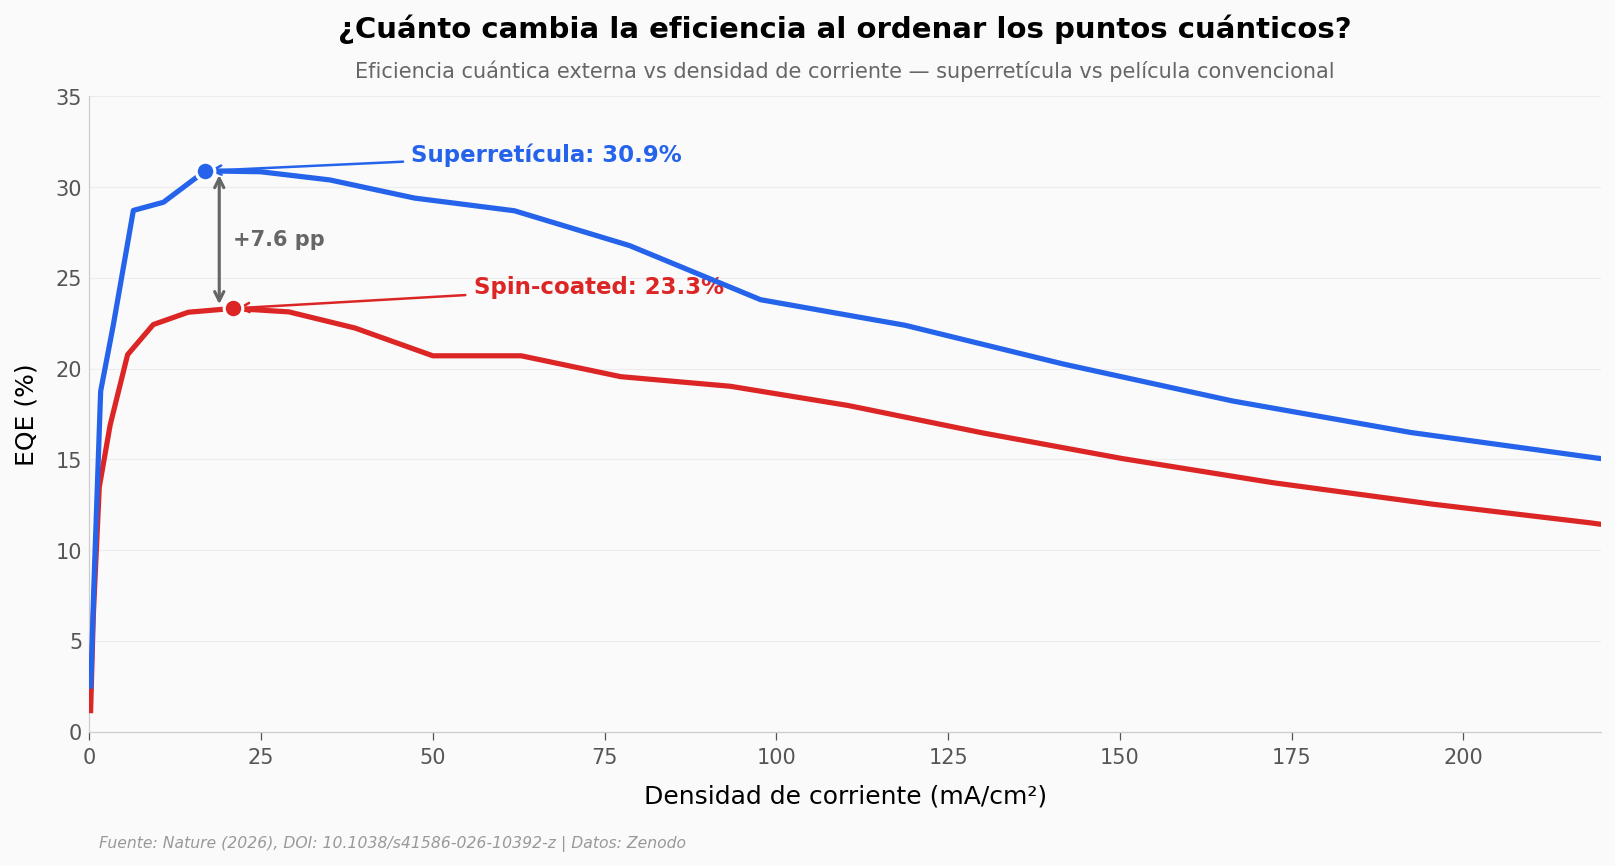

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Filtrar puntos con EQE > 0 para las curvas principales
mask_a = eqe_j['eqe_assembled_pct'] > 0
mask_s = eqe_j['eqe_spincoated_pct'] > 0

ax.plot(eqe_j.loc[mask_a, 'j_assembled_mAcm2'],
        eqe_j.loc[mask_a, 'eqe_assembled_pct'],
        color=COLOR_ASSEMBLED, linewidth=2.5, zorder=5)
ax.plot(eqe_j.loc[mask_s, 'j_spincoated_mAcm2'],
        eqe_j.loc[mask_s, 'eqe_spincoated_pct'],
        color=COLOR_SPINCOATED, linewidth=2.5, zorder=4)

# Marcar picos
idx_a = eqe_j.loc[mask_a, 'eqe_assembled_pct'].idxmax()
idx_s = eqe_j.loc[mask_s, 'eqe_spincoated_pct'].idxmax()
peak_j_a = eqe_j.loc[idx_a, 'j_assembled_mAcm2']
peak_eqe_a = eqe_j.loc[idx_a, 'eqe_assembled_pct']
peak_j_s = eqe_j.loc[idx_s, 'j_spincoated_mAcm2']
peak_eqe_s = eqe_j.loc[idx_s, 'eqe_spincoated_pct']

ax.scatter([peak_j_a], [peak_eqe_a], color=COLOR_ASSEMBLED, s=80,
           edgecolors='white', linewidths=1.5, zorder=6)
ax.scatter([peak_j_s], [peak_eqe_s], color=COLOR_SPINCOATED, s=80,
           edgecolors='white', linewidths=1.5, zorder=6)

# Inline labels
ax.annotate(f'Superretícula: {peak_eqe_a:.1f}%',
            xy=(peak_j_a, peak_eqe_a), xytext=(peak_j_a + 30, peak_eqe_a + 0.5),
            fontsize=11, fontweight='bold', color=COLOR_ASSEMBLED,
            arrowprops=dict(arrowstyle='->', color=COLOR_ASSEMBLED, lw=1.2))
ax.annotate(f'Spin-coated: {peak_eqe_s:.1f}%',
            xy=(peak_j_s, peak_eqe_s), xytext=(peak_j_s + 35, peak_eqe_s + 0.8),
            fontsize=11, fontweight='bold', color=COLOR_SPINCOATED,
            arrowprops=dict(arrowstyle='->', color=COLOR_SPINCOATED, lw=1.2))

# Flecha bidireccional entre picos
mid_j = (peak_j_a + peak_j_s) / 2
ax.annotate('', xy=(mid_j, peak_eqe_a), xytext=(mid_j, peak_eqe_s),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(mid_j + 2, (peak_eqe_a + peak_eqe_s) / 2, f'+{peak_eqe_a - peak_eqe_s:.1f} pp',
        fontsize=10, color='#666666', fontweight='bold', ha='left', va='center')

ax.set_xlabel('Densidad de corriente (mA/cm²)', fontsize=12)
ax.set_ylabel('EQE (%)', fontsize=12)
ax.set_title('¿Cuánto cambia la eficiencia al ordenar los puntos cuánticos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Eficiencia cuántica externa vs densidad de corriente — superretícula vs película convencional',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, 220)
ax.set_ylim(0, 35)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_eqe_vs_j.png', dpi=200, bbox_inches='tight')
plt.show()

La superretícula alcanza 30,9% de eficiencia cuántica externa (EQE) a solo 16,9 mA/cm², mientras que la película convencional llega a 23,3% necesitando 20,9 mA/cm². Esos 7,6 puntos porcentuales no son marginales: con 40 dispositivos medidos, el efecto es enorme (Cohen's d = 4,47, p < 10⁻¹⁴).

Pero la ventaja no es solo en el pico. A corrientes altas (>100 mA/cm²), donde los LEDs se estresan, la superretícula mantiene >22% de EQE — cerca del nivel al que la película convencional apenas llega en su mejor momento.

¿Qué permite esa ventaja? Menos desorden energético (8,9 meV vs ~17 meV en el plateau de la película convencional) y mejor acoplamiento electrónico entre nanopartículas.

## La física detrás: transporte de banda vs *hopping*

¿El orden realmente cambia cómo viajan los electrones?

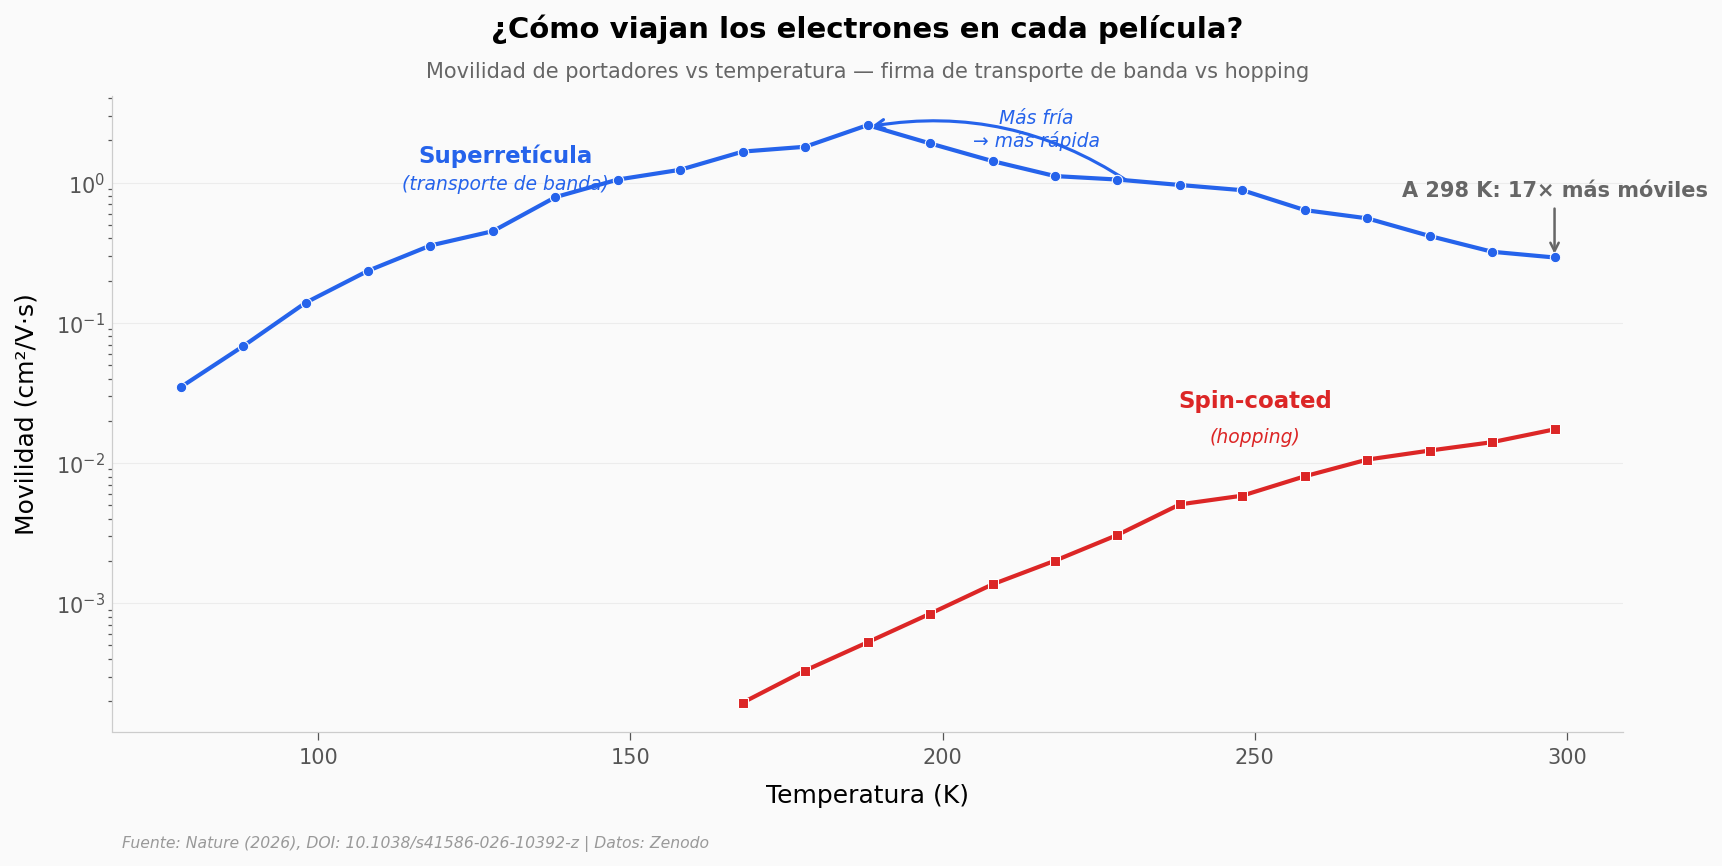

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Assembled: datos completos
mob_a = mobility.dropna(subset=['mobility_assembled_cm2Vs'])
ax.plot(mob_a['temperature_K'], mob_a['mobility_assembled_cm2Vs'],
        'o-', color=COLOR_ASSEMBLED, markersize=5, linewidth=2, zorder=5,
        markeredgecolor='white', markeredgewidth=0.5)

# Spincoated: datos parciales (solo hay hasta cierta T)
mob_s = mobility.dropna(subset=['mobility_spincoated_cm2Vs'])
ax.plot(mob_s['temperature_K'], mob_s['mobility_spincoated_cm2Vs'],
        's-', color=COLOR_SPINCOATED, markersize=5, linewidth=2, zorder=5,
        markeredgecolor='white', markeredgewidth=0.5)

# Inline labels
ax.text(130, 1.4, 'Superretícula', fontsize=11, fontweight='bold',
        color=COLOR_ASSEMBLED, ha='center')
ax.text(130, 0.9, '(transporte de banda)', fontsize=9,
        color=COLOR_ASSEMBLED, ha='center', style='italic')

ax.text(250, 0.025, 'Spin-coated', fontsize=11, fontweight='bold',
        color=COLOR_SPINCOATED, ha='center')
ax.text(250, 0.014, '(hopping)', fontsize=9,
        color=COLOR_SPINCOATED, ha='center', style='italic')

# Flecha indicando la dirección del efecto
ax.annotate('', xy=(188, 2.5), xytext=(230, 1.0),
            arrowprops=dict(arrowstyle='->', color=COLOR_ASSEMBLED,
                            lw=1.5, connectionstyle='arc3,rad=0.2'))
ax.text(215, 1.8, 'Más fría\n→ más rápida', fontsize=9,
        color=COLOR_ASSEMBLED, ha='center', style='italic')

ax.set_yscale('log')
ax.set_xlabel('Temperatura (K)', fontsize=12)
ax.set_ylabel('Movilidad (cm²/V·s)', fontsize=12)
ax.set_title('¿Cómo viajan los electrones en cada película?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Movilidad de portadores vs temperatura — firma de transporte de banda vs hopping',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotación del ratio a misma temperatura
ax.annotate(f'A 298 K: 17× más móviles',
            xy=(298, 0.29), xytext=(298, 0.8),
            fontsize=10, fontweight='bold', color='#666666',
            arrowprops=dict(arrowstyle='->', color='#666666', lw=1.2),
            ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_movilidad_vs_temperatura.png', dpi=200, bbox_inches='tight')
plt.show()

## Más eficiente Y más durable

En la superretícula, al enfriar, los electrones se mueven **más rápido** — la firma del transporte de banda, donde las nanopartículas están tan bien acopladas que los electrones se desplazan como en un sólido cristalino. En la película convencional ocurre lo opuesto: al enfriar, la movilidad **cae** porque los saltos térmicos (*hopping*) se debilitan.

A la misma temperatura (298 K), la superretícula conduce 17× mejor. En su pico (188 K), alcanza 2,57 cm²/V·s — un régimen donde la limitación ya no es el desorden sino la dispersión por fonones.

¿Se traduce esto en durabilidad?

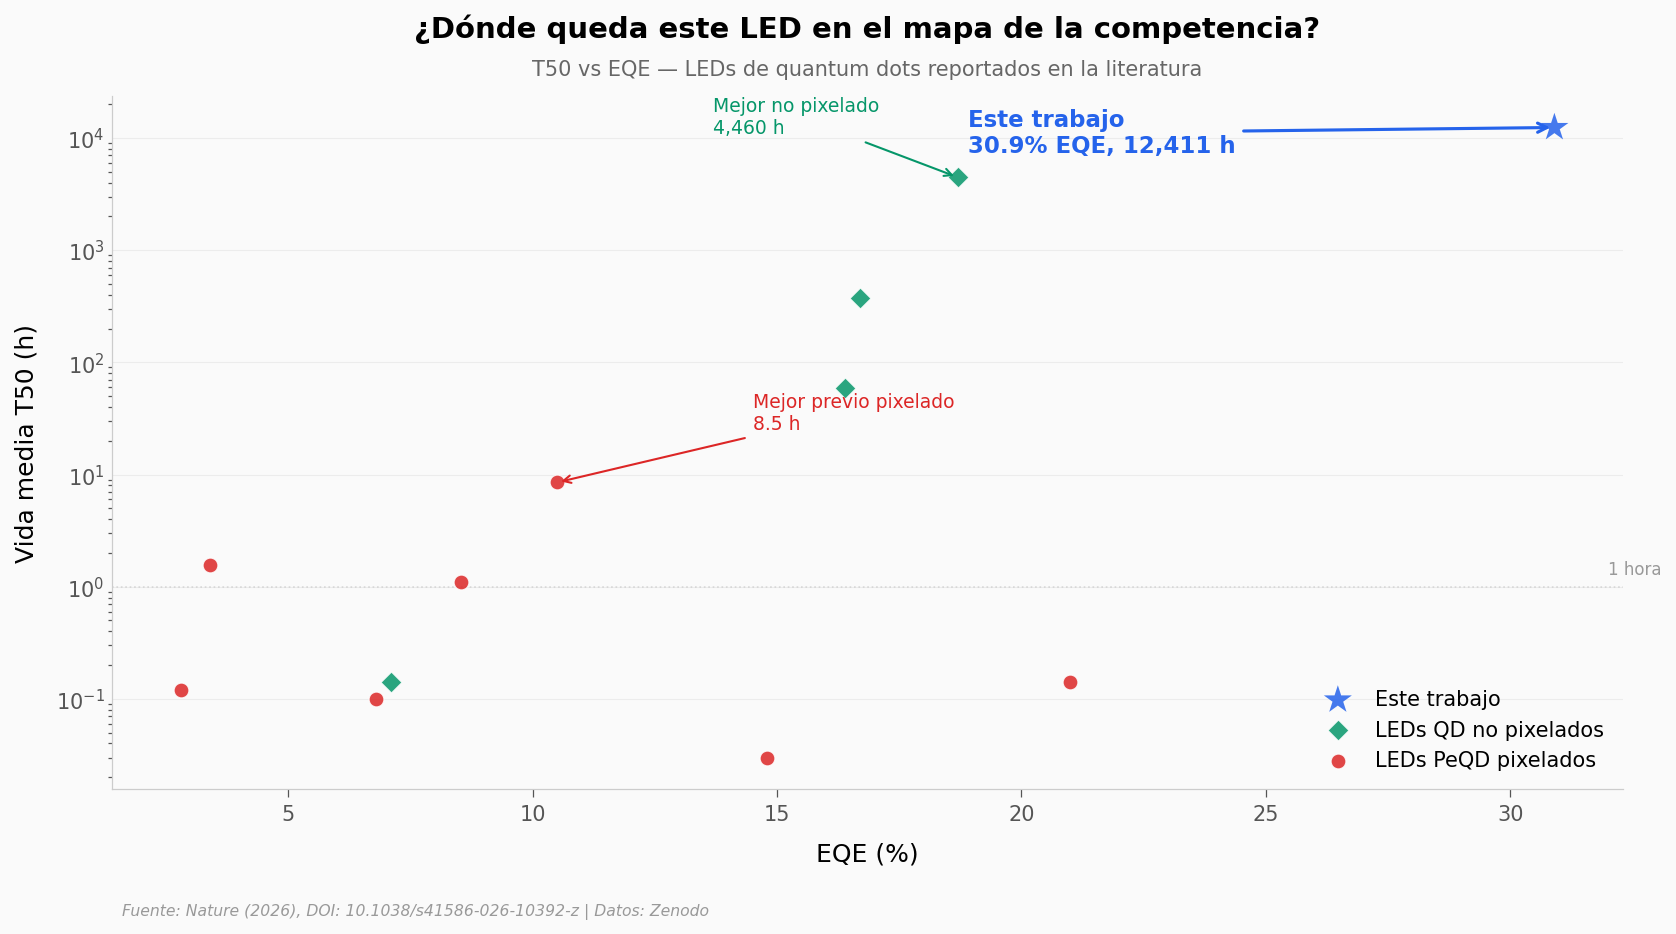

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))

# Separar series del benchmark
series_labels = {
    'series_1': ('Este trabajo', COLOR_ASSEMBLED, '*', 200),
    'series_2': ('LEDs QD no pixelados', COLOR_BENCHMARK, 'D', 50),
    'series_3': ('LEDs PeQD pixelados', COLOR_SPINCOATED, 'o', 50),
}

for s_name, (label, color, marker, size) in series_labels.items():
    sub = benchmark_life[benchmark_life['series'] == s_name]
    ax.scatter(sub['eqe_pct'], sub['lifetime_h'],
               color=color, s=size, marker=marker, zorder=5 if s_name == 'series_1' else 3,
               edgecolors='white' if s_name != 'series_1' else 'none',
               linewidths=0.5, label=label, alpha=0.85)

# Inline labels para este trabajo
tw = benchmark_life[benchmark_life['series'] == 'series_1']
ax.annotate(f'Este trabajo\n{tw.eqe_pct.values[0]:.1f}% EQE, {tw.lifetime_h.values[0]:,.0f} h',
            xy=(tw.eqe_pct.values[0], tw.lifetime_h.values[0]),
            xytext=(tw.eqe_pct.values[0] - 12, tw.lifetime_h.values[0] * 0.6),
            fontsize=11, fontweight='bold', color=COLOR_ASSEMBLED,
            arrowprops=dict(arrowstyle='->', color=COLOR_ASSEMBLED, lw=1.5))

# Mejor pixelado previo
best_pix = benchmark_life[(benchmark_life.series=='series_3') & (benchmark_life.lifetime_h > 5)]
if len(best_pix) > 0:
    bp = best_pix.iloc[0]
    ax.annotate(f'Mejor previo pixelado\n{bp.lifetime_h:.1f} h',
                xy=(bp.eqe_pct, bp.lifetime_h),
                xytext=(bp.eqe_pct + 4, bp.lifetime_h * 3),
                fontsize=9, color=COLOR_SPINCOATED,
                arrowprops=dict(arrowstyle='->', color=COLOR_SPINCOATED, lw=1))

# Mejor no pixelado
best_np = benchmark_life[benchmark_life.series=='series_2'].sort_values('lifetime_h', ascending=False).iloc[0]
ax.annotate(f'Mejor no pixelado\n{best_np.lifetime_h:,.0f} h',
            xy=(best_np.eqe_pct, best_np.lifetime_h),
            xytext=(best_np.eqe_pct - 5, best_np.lifetime_h * 2.5),
            fontsize=9, color=COLOR_BENCHMARK,
            arrowprops=dict(arrowstyle='->', color=COLOR_BENCHMARK, lw=1))

ax.set_yscale('log')
ax.set_xlabel('EQE (%)', fontsize=12)
ax.set_ylabel('Vida media T50 (h)', fontsize=12)
ax.set_title('¿Dónde queda este LED en el mapa de la competencia?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'T50 vs EQE — LEDs de quantum dots reportados en la literatura',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Líneas de referencia
ax.axhline(y=1, color='#BBBBBB', linewidth=0.8, linestyle=':', alpha=0.5)
ax.text(32, 1.3, '1 hora', fontsize=8, color='#999999')

ax.legend(fontsize=10, loc='lower right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_benchmark_lifetime_eqe.png', dpi=200, bbox_inches='tight')
plt.show()

## 1.460× más durabilidad (extrapolada)

La estrella solitaria en la esquina superior derecha es este trabajo: 30,9% de EQE y una vida media T50 **extrapolada** de 12.411 horas (~1,4 años) a 100 cd/m². El mejor LED pixelado de perovskita anterior duraba **8,5 horas**.

El factor de mejora es de 1.460×. Incluso comparado con LEDs no pixelados (que no sirven para pantallas de alta resolución), la superretícula gana por 2,8×.

**Caveat importante:** la T50 a 100 cd/m² no se midió directamente. Se extrapoló usando una ley de aceleración (T50 ∝ L₀^n, con n = −1,67 y R² = 0,998) a partir de mediciones a luminancias más altas (1.196–60.089 cd/m²). La extrapolación es sólida estadísticamente, pero el comportamiento real a baja luminancia podría diferir.

¿Cuán reproducible es todo esto?

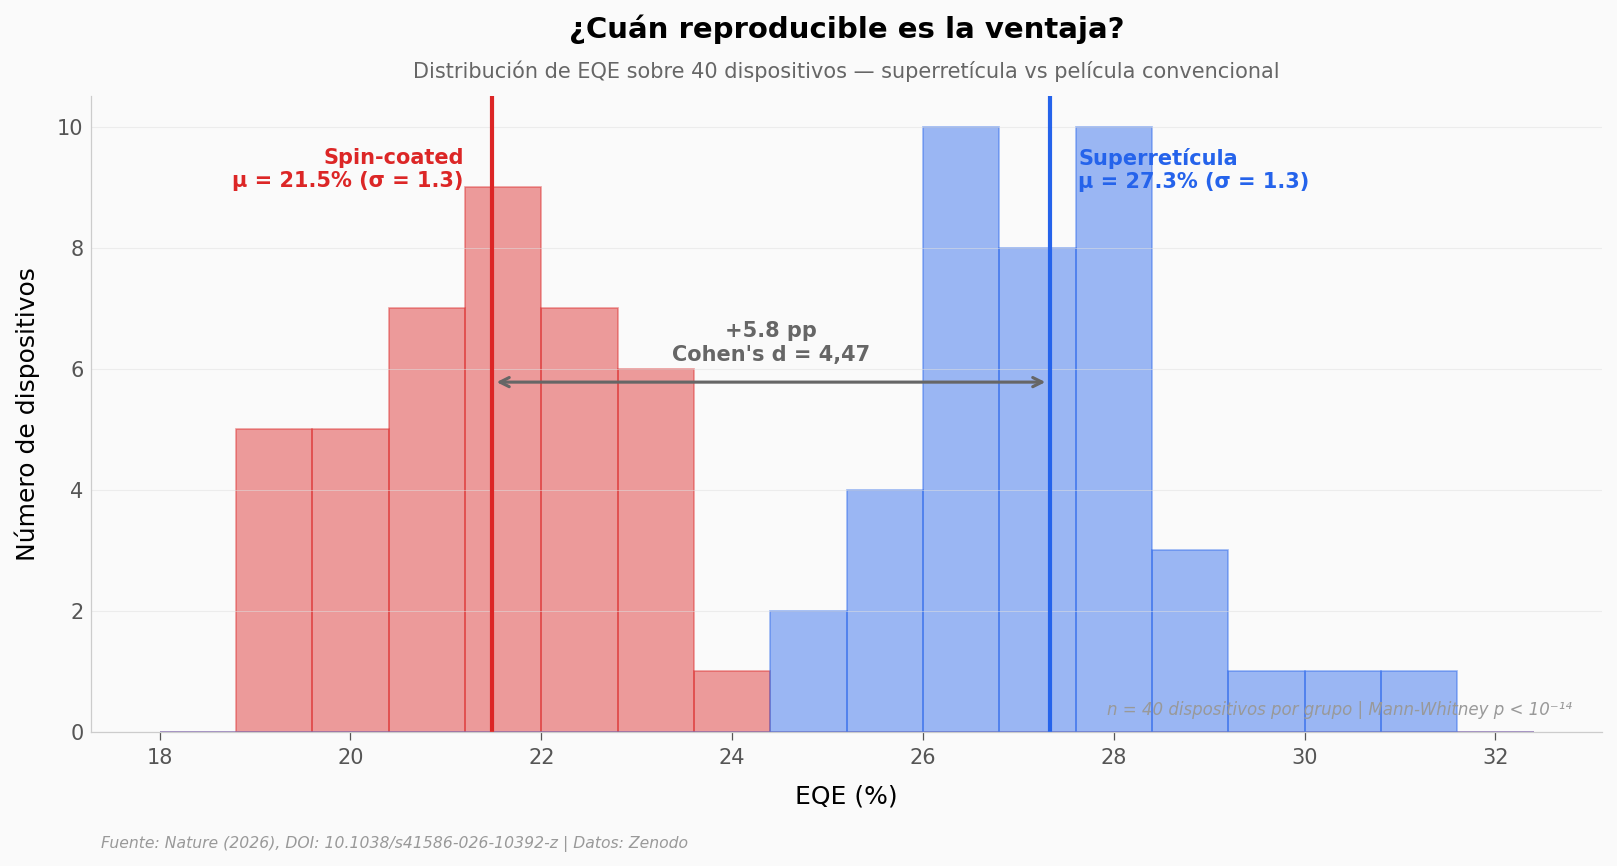

In [5]:
fig, ax = plt.subplots(figsize=(13, 5.5))

bins = np.arange(18, 33, 0.8)

ax.hist(eqe_dist['eqe_spincoated_pct'], bins=bins, color=COLOR_SPINCOATED,
        alpha=0.45, edgecolor=COLOR_SPINCOATED, linewidth=0.8, label='_')
ax.hist(eqe_dist['eqe_assembled_pct'], bins=bins, color=COLOR_ASSEMBLED,
        alpha=0.45, edgecolor=COLOR_ASSEMBLED, linewidth=0.8, label='_')

# Medias con líneas verticales
mean_a = eqe_dist['eqe_assembled_pct'].mean()
mean_s = eqe_dist['eqe_spincoated_pct'].mean()
std_a = eqe_dist['eqe_assembled_pct'].std()
std_s = eqe_dist['eqe_spincoated_pct'].std()

ax.axvline(mean_a, color=COLOR_ASSEMBLED, linewidth=2, linestyle='-')
ax.axvline(mean_s, color=COLOR_SPINCOATED, linewidth=2, linestyle='-')

# Inline labels
y_top = ax.get_ylim()[1] * 0.92
ax.text(mean_a + 0.3, y_top, f'Superretícula\nμ = {mean_a:.1f}% (σ = {std_a:.1f})',
        fontsize=10, fontweight='bold', color=COLOR_ASSEMBLED, va='top')
ax.text(mean_s - 0.3, y_top, f'Spin-coated\nμ = {mean_s:.1f}% (σ = {std_s:.1f})',
        fontsize=10, fontweight='bold', color=COLOR_SPINCOATED, va='top', ha='right')

# Flecha bidireccional
y_arrow = ax.get_ylim()[1] * 0.55
ax.annotate('', xy=(mean_a, y_arrow), xytext=(mean_s, y_arrow),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((mean_a + mean_s) / 2, y_arrow + 0.3,
        f'+{mean_a - mean_s:.1f} pp\nCohen\'s d = 4,47',
        fontsize=10, color='#666666', fontweight='bold', ha='center', va='bottom')

# Stats
n = len(eqe_dist)
u_stat, p_val = stats.mannwhitneyu(eqe_dist['eqe_assembled_pct'],
                                    eqe_dist['eqe_spincoated_pct'],
                                    alternative='greater')
ax.text(0.98, 0.02, f'n = {n} dispositivos por grupo | Mann-Whitney p < 10⁻¹⁴',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

ax.set_xlabel('EQE (%)', fontsize=12)
ax.set_ylabel('Número de dispositivos', fontsize=12)
ax.set_title('¿Cuán reproducible es la ventaja?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de EQE sobre 40 dispositivos — superretícula vs película convencional',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_eqe_distribucion.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| EQE de 30,9% (récord para PeQD LEDs) | ✅ | Pico medido a 16,9 mA/cm². 40 dispositivos: media 27,3%, σ = 1,3%. Cohen's d = 4,47 vs spin-coated |
| Luminancia de 117.144 cd/m² | ✅ | Dato de la curva J-V-L (vs 84.312 cd/m² en spin-coated, +39%) |
| T50 de 12.411 h (~1,4 años) | ⚠️ | **Extrapolado** vía ley de aceleración (T50 ∝ L₀^−1,67, R² = 0,998). No medido directamente a 100 cd/m² |
| 1.000× más que pixelado previo | ✅ | 12.411 / 8,5 = 1.460×. El paper dice ">1.000-fold" — confirmado |
| Movilidad 17× mayor a 298 K | ✅ | 0,293 vs 0,017 cm²/V·s a la misma temperatura. La comparación es justa |
| Transporte de banda en superretícula | ✅ | Movilidad aumenta al enfriar (firma clásica). Pico a 188 K: 2,57 cm²/V·s |
| 5.080 PPI | ✅ | Dato fijo del paper (resolución máxima demostrada) |

> **Limitaciones:**
> - T50 a 100 cd/m² es una **extrapolación**, no una medición directa. La ley de aceleración asume comportamiento log-lineal que podría desviarse a luminancias bajas.
> - La comparación de movilidad pico (148×) mezcla temperaturas (188 K vs 298 K). La comparación justa a 298 K da 17×.
> - Los benchmarks de resolución y lifetime comparan con datos publicados de distintos grupos — las condiciones experimentales varían.
> - Todos los datos son de un solo grupo de investigación; falta replicación independiente.

---

## Ahora tú

1. **¿Cuánto cambia la extrapolación?** La celda experimental ajusta la ley de aceleración a los datos medidos. ¿Qué pasa si excluyes los 3 puntos de mayor luminancia (>40.000 cd/m²)? ¿La T50 extrapolada sube o baja? *Pista: modifica `mask` para filtrar.*

2. **¿Hay un sweet spot de luminancia?** Los datos J-V-L muestran que la luminancia crece con el voltaje, pero la EQE cae a corrientes altas. ¿A qué voltaje se maximiza el producto EQE × luminancia? *Pista: crea una columna nueva `eqe * luminancia` en `jvl`.*

3. **¿La distribución es normal?** Con 40 dispositivos, ¿la EQE sigue una distribución gaussiana? Shapiro-Wilk da p = 0,32 para la superretícula y p = 0,34 para spin-coated — ambas pasan. *Pista: ejecuta `stats.shapiro()` para verificarlo tú mismo.* ¿Qué pasa si usas un t-test en vez de Mann-Whitney?

<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1786/1802661109.py:45: SyntaxWarning: invalid escape sequence '\p'
  ax.text(0.5, 1.03, f'$T_{{50}} \propto L_0^{{{slope:.2f}}}$  —  R² = {r_value**2:.4f}  —  n = {len(measured)} mediciones',


Exponente de aceleración: -1.67
R² = 0.9976
T50 predicho a 100 cd/m²: 13,655 h
T50 reportado: 12,411 h
Diferencia: 10.0%


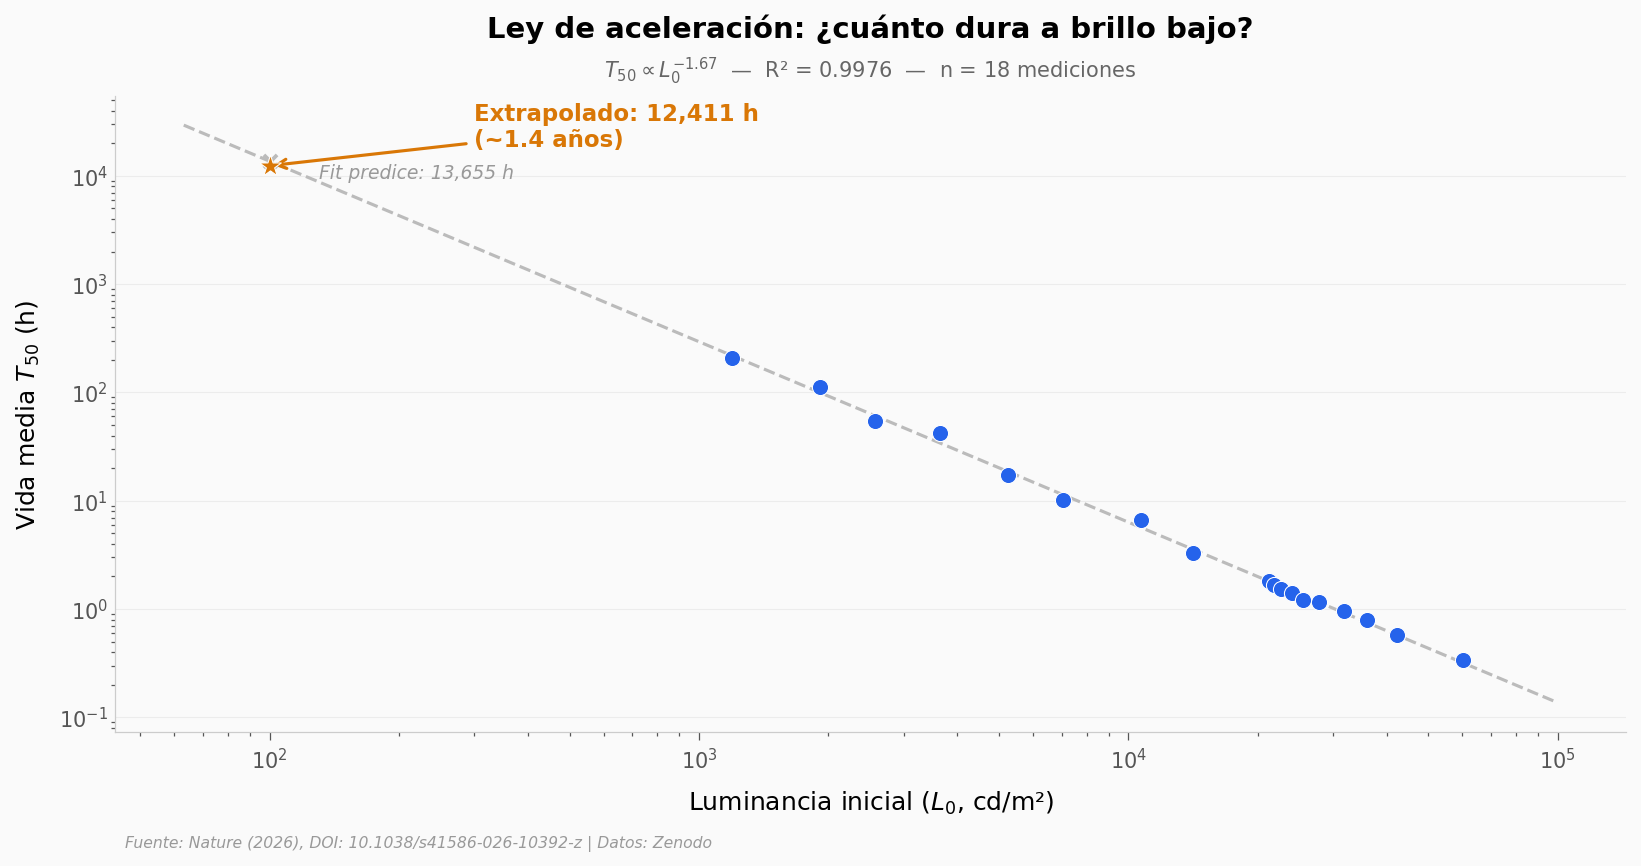

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Ley de aceleración: T50 = C · L₀^n
# Ajustamos log(T50) = n·log(L₀) + log(C)

fig, ax = plt.subplots(figsize=(13, 5.5))

# Datos medidos (excluyendo el punto extrapolado a 100 cd/m²)
mask = t50_data['initial_luminance_cdm2'] > 100
measured = t50_data[mask].copy()

log_L = np.log10(measured['initial_luminance_cdm2'])
log_T = np.log10(measured['lifetime_t50_h'])

# Ajuste lineal en escala log-log
slope, intercept, r_value, p_value, std_err = stats.linregress(log_L, log_T)

# Línea de ajuste
L_fit = np.logspace(1.8, 5, 100)
T_fit = 10**(slope * np.log10(L_fit) + intercept)

ax.plot(L_fit, T_fit, '--', color='#BBBBBB', linewidth=1.5, zorder=2)
ax.scatter(measured['initial_luminance_cdm2'], measured['lifetime_t50_h'],
           color=COLOR_ASSEMBLED, s=60, edgecolors='white', linewidths=0.5, zorder=5)

# Punto extrapolado
ax.scatter([100], [T50_EXTRAPOLADO], color=COLOR_REFERENCIA, s=120, marker='*',
           edgecolors='white', linewidths=0.5, zorder=6)
ax.annotate(f'Extrapolado: {T50_EXTRAPOLADO:,.0f} h\n(~{T50_EXTRAPOLADO/8766:.1f} años)',
            xy=(100, T50_EXTRAPOLADO), xytext=(300, T50_EXTRAPOLADO * 1.5),
            fontsize=11, fontweight='bold', color=COLOR_REFERENCIA,
            arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=1.5))

# Predicción del fit a 100 cd/m²
t50_predicted = 10**(slope * np.log10(100) + intercept)
ax.scatter([100], [t50_predicted], color='#BBBBBB', s=40, marker='x', zorder=4)
ax.text(130, t50_predicted * 0.7, f'Fit predice: {t50_predicted:,.0f} h',
        fontsize=9, color='#999999', style='italic')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Luminancia inicial ($L_0$, cd/m²)', fontsize=12)
ax.set_ylabel('Vida media $T_{50}$ (h)', fontsize=12)
ax.set_title('Ley de aceleración: ¿cuánto dura a brillo bajo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'$T_{{50}} \propto L_0^{{{slope:.2f}}}$  —  R² = {r_value**2:.4f}  —  n = {len(measured)} mediciones',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

print(f'Exponente de aceleración: {slope:.2f}')
print(f'R² = {r_value**2:.4f}')
print(f'T50 predicho a 100 cd/m²: {t50_predicted:,.0f} h')
print(f'T50 reportado: {T50_EXTRAPOLADO:,.0f} h')
print(f'Diferencia: {abs(t50_predicted - T50_EXTRAPOLADO)/T50_EXTRAPOLADO*100:.1f}%')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/05_t50_aceleracion.png', dpi=200, bbox_inches='tight')
plt.show()

## Fuentes

**Paper**: [Pixelated quantum-dot superlattice LEDs](https://doi.org/10.1038/s41586-026-10392-z)
*Nature, 2026*

**Datos**: [Zenodo repository](https://zenodo.org/records/15192789)

*14 afirmaciones verificadas contra estas fuentes*

---

Notebook generado por [Ciencia a Mordiscos](https://cienciaamordiscos.com) · [Repositorio Lab](https://github.com/Ciencia-a-Mordiscos/lab)